In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/car-purchasing-model/Car_Purchasing_Data.csv


In [2]:
df=pd.read_csv('/kaggle/input/car-purchasing-model/Car_Purchasing_Data.csv')

In [3]:
df.head()

,Customer Name,Customer e-mail,Country,Gender,Age,Annual Salary,Credit Card Debt,Net Worth,Car Purchase Amount
0,Martina Avila,cubilia.Curae.Phasellus@quisaccumsanconvallis.edu,USA,0,42,62812.09301,11609.380910,238961.2505,35321.45877
1,Harlan Barnes,eu.dolor@diam.co.uk,USA,0,41,66646.89292,9572.957136,530973.9078,45115.52566
2,Naomi Rodriquez,vulputate.mauris.sagittis@ametconsectetueradip...,USA,1,43,53798.55112,11160.355060,638467.1773,42925.70921
3,Jade Cunningham,malesuada@dignissim.com,USA,1,58,79370.03798,14426.164850,548599.0524,67422.36313
4,Cedric Leach,felis.ullamcorper.viverra@egetmollislectus.net,USA,1,57,59729.15130,5358.712177,560304.0671,55915.46248


In [4]:
df.drop(['Customer Name','Customer e-mail'],inplace=True,axis=1)

In [5]:
df.head()

,Country,Gender,Age,Annual Salary,Credit Card Debt,Net Worth,Car Purchase Amount
0,USA,0,42,62812.09301,11609.380910,238961.2505,35321.45877
1,USA,0,41,66646.89292,9572.957136,530973.9078,45115.52566
2,USA,1,43,53798.55112,11160.355060,638467.1773,42925.70921
3,USA,1,58,79370.03798,14426.164850,548599.0524,67422.36313
4,USA,1,57,59729.15130,5358.712177,560304.0671,55915.46248


In [6]:
df['Country'].unique()

array(['USA'], dtype=object)

In [7]:
df.drop('Country',axis=1,inplace=True)

In [8]:
df.head()

,Gender,Age,Annual Salary,Credit Card Debt,Net Worth,Car Purchase Amount
0,0,42,62812.09301,11609.380910,238961.2505,35321.45877
1,0,41,66646.89292,9572.957136,530973.9078,45115.52566
2,1,43,53798.55112,11160.355060,638467.1773,42925.70921
3,1,58,79370.03798,14426.164850,548599.0524,67422.36313
4,1,57,59729.15130,5358.712177,560304.0671,55915.46248


In [9]:
df.skew()

Gender                -0.024074
Age                    0.008082
Annual Salary         -0.087478
Credit Card Debt      -0.063724
Net Worth              0.139755
Car Purchase Amount   -0.030791
dtype: float64

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

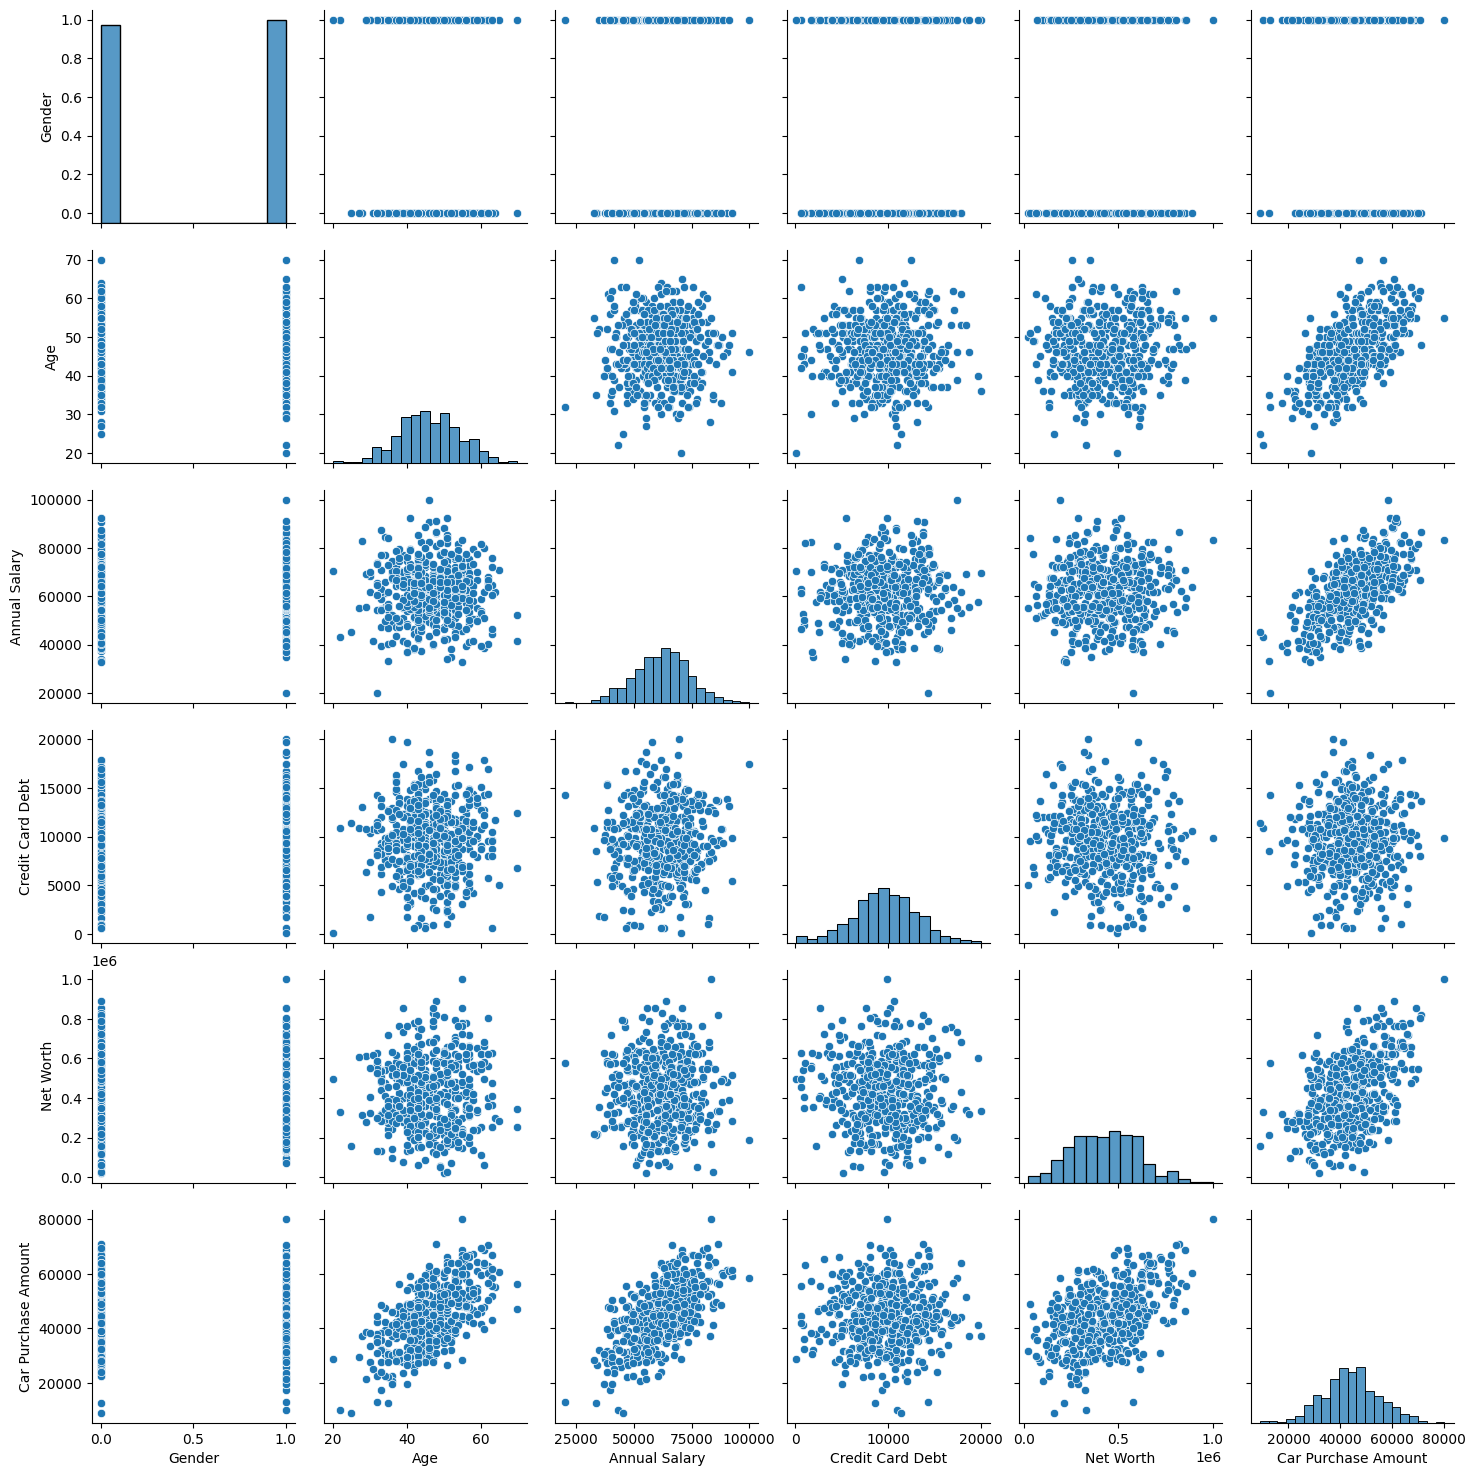

In [11]:
sns.pairplot(df)

<Axes: >

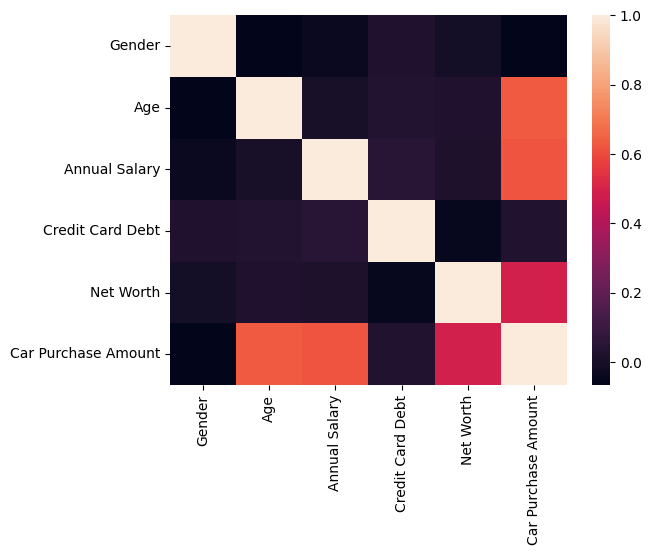

In [12]:
sns.heatmap(df.corr())

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


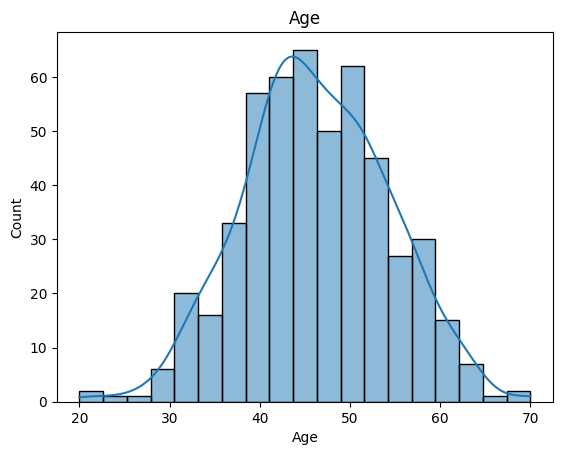

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


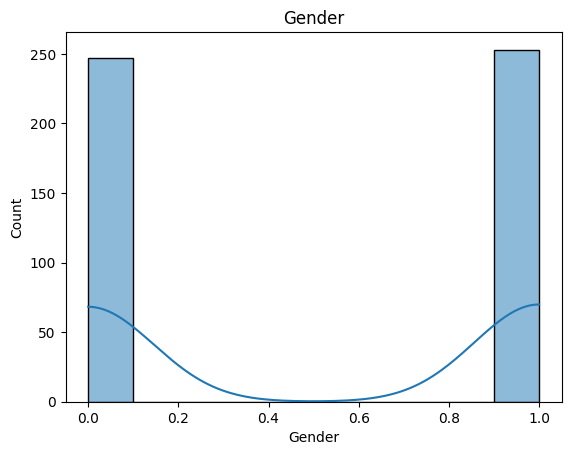

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


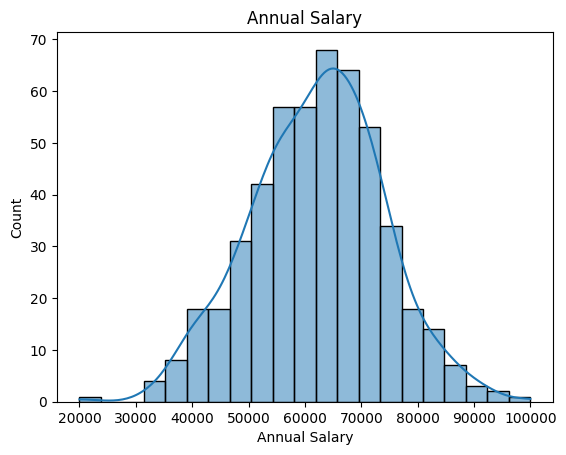

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


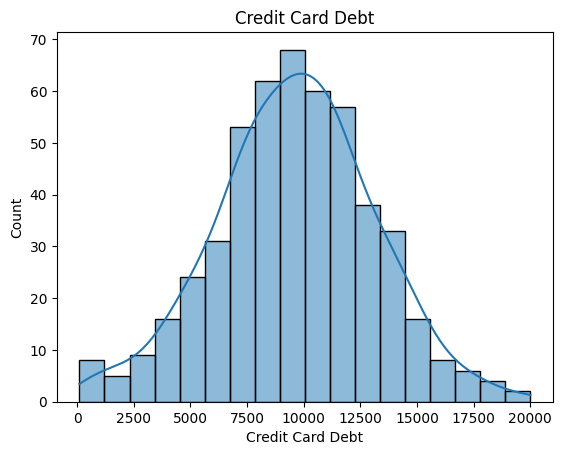

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


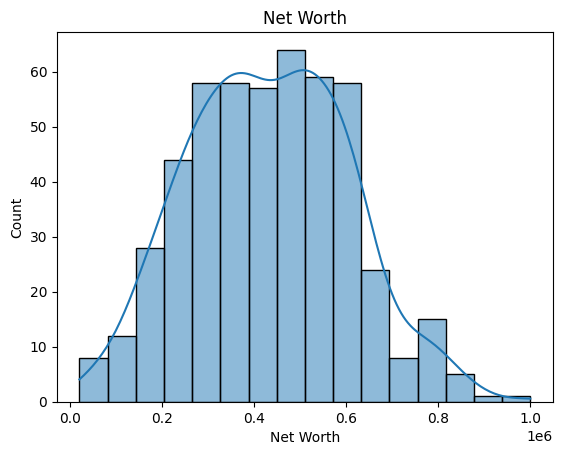

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


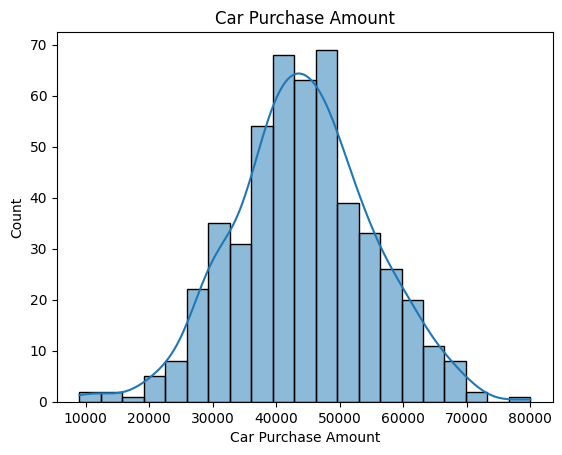

In [13]:
col=['Age','Gender','Annual Salary','Credit Card Debt','Net Worth','Car Purchase Amount']

for i in col:
    sns.histplot(df[i],kde=True)
    plt.title(f'{i}')
    plt.show()

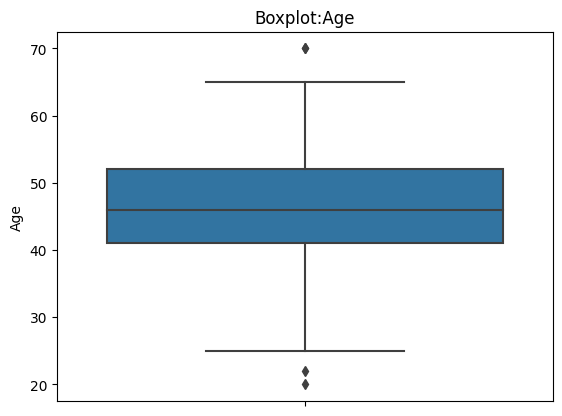

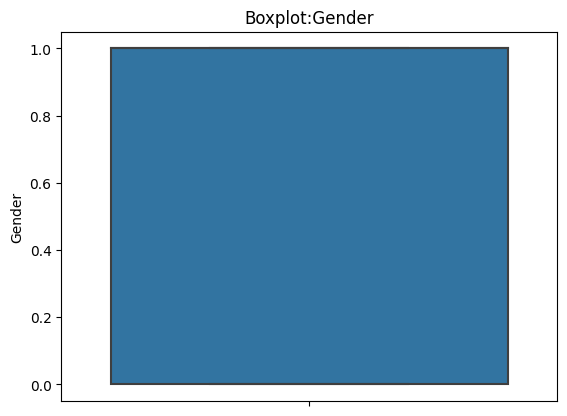

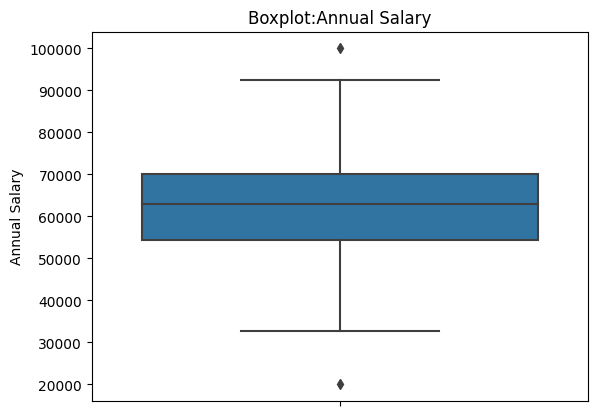

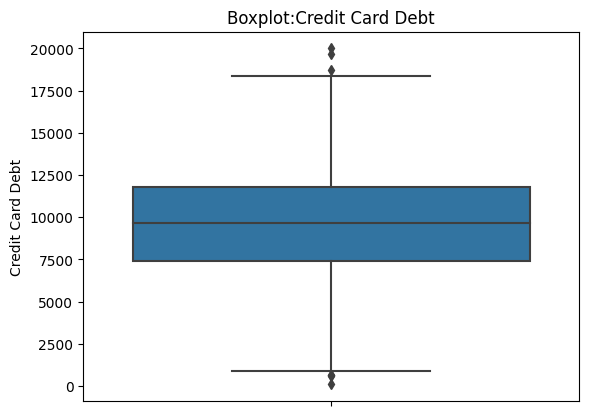

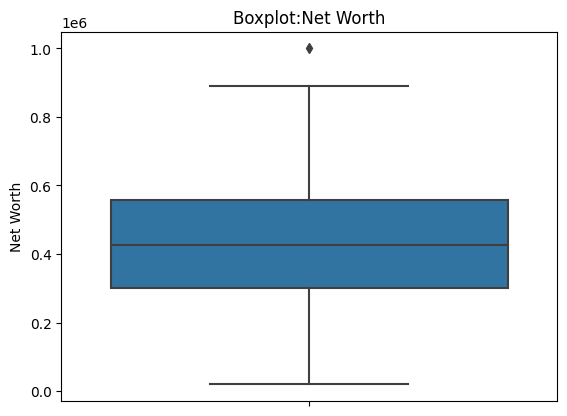

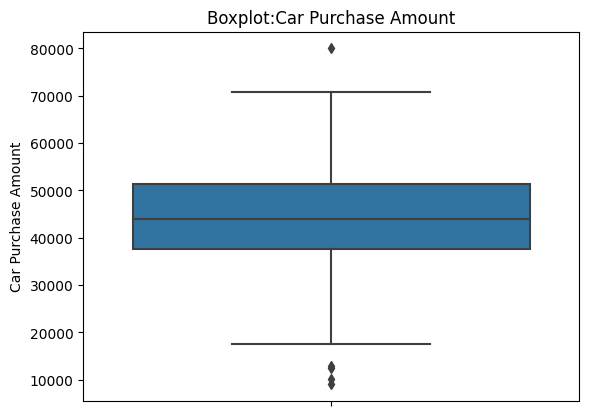

In [14]:
for i in col:
    
    sns.boxplot(y=df[i])
    plt.title(f"Boxplot:{i}")
    plt.show()

In [15]:
upper_limit= df['Age'].mean()+3*df['Age'].std()
lower_limit=df['Age'].mean()-3*df['Age'].std()

In [16]:
upper_limit, lower_limit

(70.19501656731606, 22.252983432683934)

In [17]:
df[(df['Age'] > upper_limit) | (df['Age'] < lower_limit)]

,Gender,Age,Annual Salary,Credit Card Debt,Net Worth,Car Purchase Amount
37,1,22,43131.78411,10917.14094,326742.7352,10092.22509
444,1,20,70467.29492,100.00000,494606.6334,28645.39425


In [18]:
for i in col:
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[i] = np.where(
        df[i] > upper, upper,
        np.where(df[i] < lower, lower, df[i])
    )


In [19]:
df[col].describe()


,Age,Gender,Annual Salary,Credit Card Debt,Net Worth,Car Purchase Amount
count,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,46.23200,0.506000,62136.259286,9603.708400,431362.863431,44241.674728
std,7.93133,0.500465,11597.537155,3465.474904,173184.295147,10586.097885
min,24.50000,0.000000,30803.149980,795.488248,20000.000000,17192.675824
25%,41.00000,0.000000,54391.977195,7397.515792,299824.195900,37629.896040
50%,46.00000,1.000000,62915.497035,9655.035568,426750.120650,43997.783390
75%,52.00000,1.000000,70117.862005,11798.867487,557324.478725,51254.709517
max,68.50000,1.000000,93706.689220,18400.895031,943574.902962,71691.929734


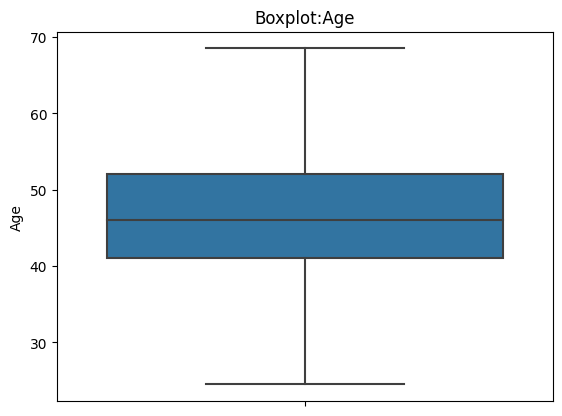

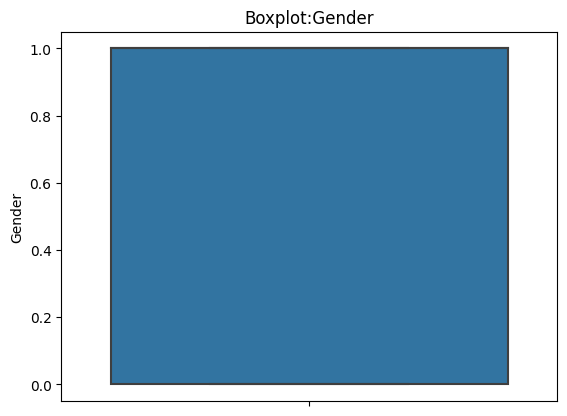

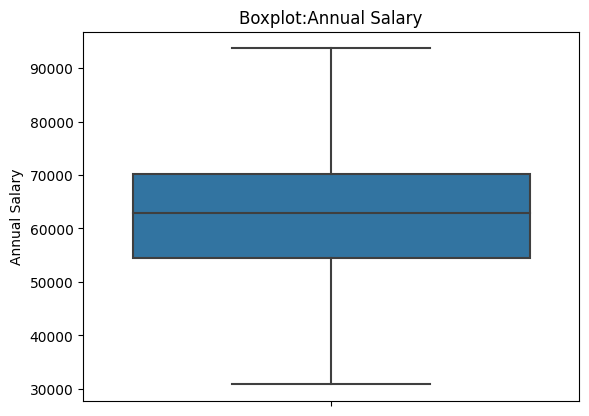

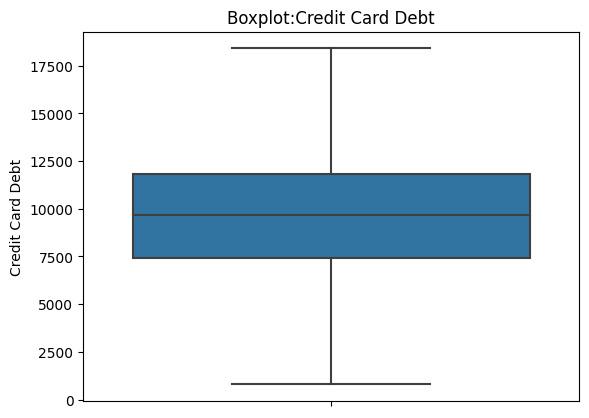

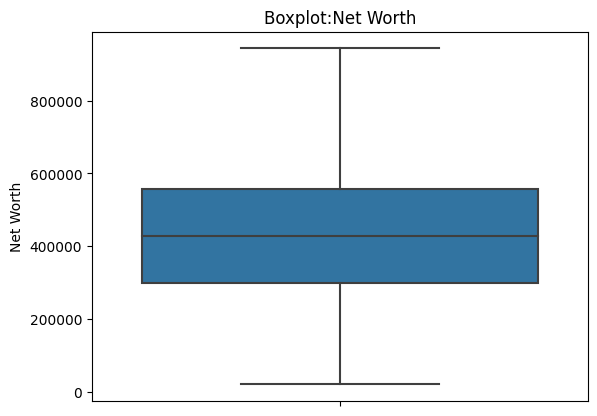

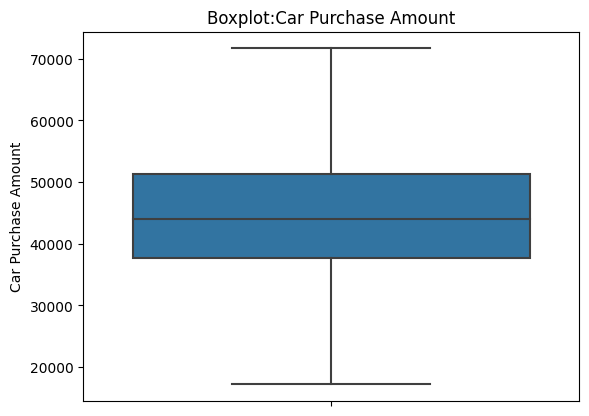

In [20]:
for i in col:
    
    sns.boxplot(y=df[i])
    plt.title(f"Boxplot:{i}")
    plt.show()

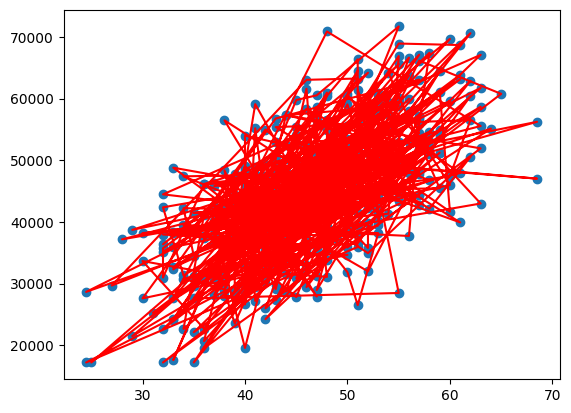

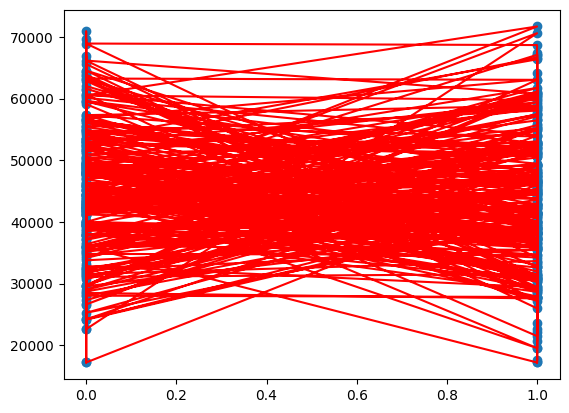

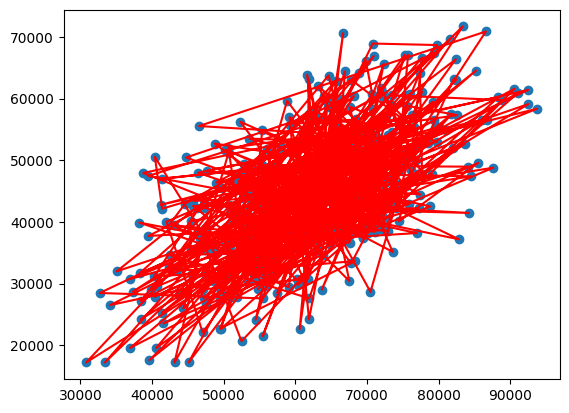

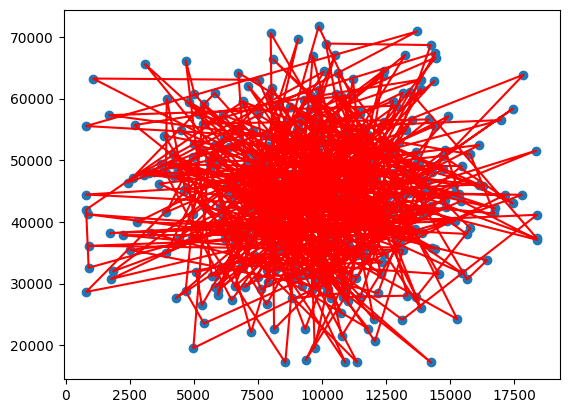

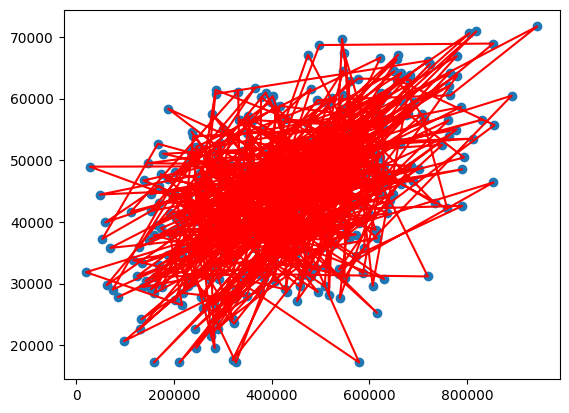

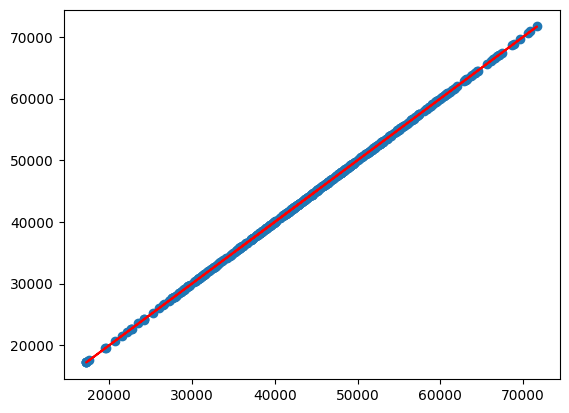

In [21]:
for i in col:
    plt.scatter(df[i],df['Car Purchase Amount'])
    plt.plot(df[i],df['Car Purchase Amount'],color='Red')
    plt.show()

In [22]:
df.head()

,Gender,Age,Annual Salary,Credit Card Debt,Net Worth,Car Purchase Amount
0,0.0,42.0,62812.09301,11609.380910,238961.2505,35321.45877
1,0.0,41.0,66646.89292,9572.957136,530973.9078,45115.52566
2,1.0,43.0,53798.55112,11160.355060,638467.1773,42925.70921
3,1.0,58.0,79370.03798,14426.164850,548599.0524,67422.36313
4,1.0,57.0,59729.15130,5358.712177,560304.0671,55915.46248


In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split as tts

In [24]:
X=df.drop('Car Purchase Amount',axis=1)
y=df['Car Purchase Amount']

In [25]:
X_train,X_test,y_train,y_test= tts(X,y,random_state=10,test_size=0.25)

In [26]:
sc= StandardScaler()


In [27]:
X_train.head()

,Gender,Age,Annual Salary,Credit Card Debt,Net Worth
324,0.0,36.0,67032.16445,7666.530300,516738.1724
252,1.0,43.0,66013.95174,7039.540023,610942.1408
441,0.0,33.0,54447.15275,13141.319690,284155.4155
427,0.0,38.0,75901.81829,6512.711020,357468.1866
70,1.0,45.0,50280.00450,11350.494080,230728.3008


In [28]:
X_test.head()

,Gender,Age,Annual Salary,Credit Card Debt,Net Worth
151,1.0,50.0,52373.79446,11347.629670,633383.4925
424,1.0,37.0,51111.76605,9057.600508,461366.7829
154,1.0,45.0,59689.81438,14862.840110,449895.3046
190,1.0,48.0,86067.83527,9181.067430,335652.6234
131,1.0,45.0,60575.12604,8088.344365,291360.0291


In [29]:
X_train=sc.fit_transform(X_train)

In [30]:
X_test=sc.transform(X_test)

In [31]:
X_test.shape

(125, 5)

In [32]:
X_train.shape

(375, 5)

In [33]:
y_train.head()

324    41137.89459
252    49079.61942
441    24134.59205
427    42905.53815
70     30841.00154
Name: Car Purchase Amount, dtype: float64

In [34]:
scaler_y = StandardScaler()

# Convert Series to NumPy array, then reshape
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

In [35]:
from sklearn.linear_model import Ridge

In [36]:
r= Ridge(alpha=3)

In [37]:
model=r.fit(X_train,y_train_scaled)

In [38]:
y_pred=model.predict(X_test)

In [39]:
from sklearn.metrics import r2_score

In [40]:
print("r2_score is: ",r2_score(y_test_scaled,y_pred))

r2_score is:  0.9987380206901817
